In [1]:
import os
import sys


GOOGLE_DRIVE_DATA = r"G:\.shortcut-targets-by-id\1ua-L70AEx_VqEEKdgxjSMzr-wEX6GnxK\voice-manipulation-detection\data\raw"

DATA_ROOT = GOOGLE_DRIVE_DATA
print(f"Using Google Drive: {DATA_ROOT}")

# For Jupyter notebooks, use os.getcwd() instead of __file__
PROJECT_ROOT = os.getcwd()

print(f"\nData root: {DATA_ROOT}")
print(f"Project root: {PROJECT_ROOT}")

# First check - data from Google Drive
print(f"\nChecking data directory...")
print(f"Accessing: {DATA_ROOT}")

try:
    if os.path.exists(DATA_ROOT):
        print(f"✓ Data directory found!")
        try:
            contents = os.listdir(DATA_ROOT)[:5]
            print(f"  Contents: {contents}")
        except Exception as e:
            print(f"  Warning: Could not list contents: {e}")
    else:
        print(f"✗ Data directory NOT found at: {DATA_ROOT}")
        print(f"\nTroubleshooting:")
        print(f"  1. Verify Google Drive shortcut is active in File Explorer")
        print(f"  2. Check that {DATA_ROOT} exists")
        print(f"  3. If path is incorrect, update GOOGLE_DRIVE_DATA variable above")
except Exception as e:
    print(f"✗ Error accessing data directory: {e}")
    print(f"  Make sure Google Drive is synced and the shortcut is accessible")

Using Google Drive: G:\.shortcut-targets-by-id\1ua-L70AEx_VqEEKdgxjSMzr-wEX6GnxK\voice-manipulation-detection\data\raw

Data root: G:\.shortcut-targets-by-id\1ua-L70AEx_VqEEKdgxjSMzr-wEX6GnxK\voice-manipulation-detection\data\raw
Project root: C:\Users\PC\Desktop\Projetcs\ISOC\M1\DeepLearning\projects\voice-manipulation-detection\notebooks

Checking data directory...
Accessing: G:\.shortcut-targets-by-id\1ua-L70AEx_VqEEKdgxjSMzr-wEX6GnxK\voice-manipulation-detection\data\raw
✓ Data directory found!
  Contents: ['ASVspoof2019']


In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\n{'='*60}")
print(f"DEVICE INFORMATION")
print(f"{'='*60}")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"\n✓ GPU is available")
else:
    print(f"\n✗ WARNING: GPU NOT DETECTED")
    print(f"\nDEBUG INFO:")
    print(f"  PyTorch Version: {torch.__version__}")
    print(f"  CUDA Compiled: {torch.version.cuda}")
    print(f"  cuDNN Compiled: {torch.backends.cudnn.version()}")
    print(f"\nTROUBLESHOOTING STEPS:")
    print(f"  1. Check NVIDIA Driver: Run 'nvidia-smi' in terminal")
    print(f"  2. Verify CUDA Installation: python -c 'import torch; print(torch.cuda.is_available())'")
    print(f"  3. If nvidia-smi works but PyTorch doesn't see GPU:")
    print(f"     → Reinstall PyTorch GPU version:")
    print(f"     → pip install torch torchvision torchaudio pytorch-cuda=12.1 -f https://download.pytorch.org/whl/torch_stable.html")
    print(f"  4. Restart Python kernel after reinstalling PyTorch")

print(f"{'='*60}\n")


DEVICE INFORMATION
Device: cuda
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Memory: 4.29 GB
CUDA Version: 12.4

✓ GPU is available



In [3]:
import sys

# Create necessary directories
models_checkpoint_dir = os.path.join(PROJECT_ROOT, 'models', 'checkpoints')
experiments_dir = os.path.join(PROJECT_ROOT, 'experiments', 'figures')

os.makedirs(models_checkpoint_dir, exist_ok=True)
os.makedirs(experiments_dir, exist_ok=True)

# Add project to path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Checkpoints dir: {models_checkpoint_dir}")
print(f"Experiments dir: {experiments_dir}")
print(f"\n✓ Directory structure ready")

Project root: C:\Users\PC\Desktop\Projetcs\ISOC\M1\DeepLearning\projects\voice-manipulation-detection\notebooks
Data root: G:\.shortcut-targets-by-id\1ua-L70AEx_VqEEKdgxjSMzr-wEX6GnxK\voice-manipulation-detection\data\raw
Checkpoints dir: C:\Users\PC\Desktop\Projetcs\ISOC\M1\DeepLearning\projects\voice-manipulation-detection\notebooks\models\checkpoints
Experiments dir: C:\Users\PC\Desktop\Projetcs\ISOC\M1\DeepLearning\projects\voice-manipulation-detection\notebooks\experiments\figures

✓ Directory structure ready


In [4]:
config = {
    'project': {
        'name': 'voice-manipulation-detection',
        'seed': 42,
        'num_workers': 2,  # For GPU, keep at 2
    },
    'paths': {
        'data_root': DATA_ROOT,
        'checkpoints': os.path.join(PROJECT_ROOT, 'models', 'checkpoints'),
        'experiments_root': os.path.join(PROJECT_ROOT, 'experiments')
    },
    'data': {
        'debug_mode': False,     
        'subset_fraction': 0.43,  # 43% data as you specified
        'max_length': 64000,      # 4 seconds at 16kHz
        'sample_rate': 16000
    },
    'model': {
        'hidden_channels': 64,      # Reduced from 128 for 4GB VRAM
        'dropout': 0.5,             # High dropout to prevent overfitting
        'label_smoothing': 0.1      # Prevent overconfidence
    },
    'training': {
        'batch_size': 32,           # Reduced from 64 for 4GB VRAM (RTX 3050)
        'num_epochs': 25,           # As you specified
        'learning_rate': 0.0001,    # OPTIMIZED: Lower LR for better generalization (ASVspoof standard)
        'weight_decay': 0.0001,     # OPTIMIZED: Standard for ASVspoof, less aggressive than 0.001
        'gradient_clip': 1.0,       # Prevent exploding gradients
        'optimizer': {
            'betas': [0.9, 0.999]
        },
        'scheduler': {
            'min_lr': 1e-7,
            'warmup_epochs': 2       # Gradual LR warmup
        },
        'early_stopping': {
            'enabled': True,
            'patience': 5,           # Stricter early stopping (prevent overfitting)
            'metric': 'eer'          # Stop based on EER, not just loss
        },
        'checkpoint': {
            'save_frequency': 5
        }
    },
    'augmentation': {
        'enabled': True,
        'mixup_alpha': 0.2,          # For regularization
        'time_stretch': True,
        'pitch_shift': True,
        'noise_augment': True
    },
    'logging': {
        'log_interval': 10
    },
    'reproducibility': {
        'deterministic': True,
        'benchmark': False          # Slower but more reproducible
    }
}

print(f"\n{'='*60}")
print(f"CONFIGURATION FOR RTX 3050 (4GB VRAM)")
print(f"OPTIMIZED FOR ASVSPOOF2019")
print(f"{'='*60}")
print(f"Batch size: {config['training']['batch_size']}")
print(f"Epochs: {config['training']['num_epochs']}")
print(f"Data: {config['data']['subset_fraction']*100:.0f}%")
print(f"LR: {config['training']['learning_rate']} (optimized)")
print(f"Weight Decay: {config['training']['weight_decay']} (optimized)")
print(f"Dropout: {config['model']['dropout']}")
print(f"Label Smoothing: {config['model']['label_smoothing']}")
print(f"Early Stopping Patience: {config['training']['early_stopping']['patience']}")
print(f"{'='*60}\n")


CONFIGURATION FOR RTX 3050 (4GB VRAM)
OPTIMIZED FOR ASVSPOOF2019
Batch size: 32
Epochs: 25
Data: 43%
LR: 0.0001 (optimized)
Weight Decay: 0.0001 (optimized)
Dropout: 0.5
Label Smoothing: 0.1
Early Stopping Patience: 5



In [5]:
print(f"\n{'='*60}")
print("CHECKING DATA DIRECTORY STRUCTURE")
print(f"{'='*60}\n")

expected_paths = [
    'ASVspoof2019/LA/LA/ASVspoof2019_LA_cm_protocols',
    'ASVspoof2019/LA/LA/ASVspoof2019_LA_train/flac',
    'ASVspoof2019/LA/LA/ASVspoof2019_LA_dev/flac',
    'ASVspoof2019/LA/LA/ASVspoof2019_LA_eval/flac'
]

all_good = True
for path in expected_paths:
    full_path = os.path.join(DATA_ROOT, path)
    exists = os.path.exists(full_path)
    status = "ok" if exists else "no"
    print(f"{status} {path}")
    if not exists:
        all_good = False

if all_good:
    print(f"\nAll required directories found!")
else:
    print(f"\nMISSING DIRECTORIES!")
    print(f"\nMake sure ASVspoof2019 LA dataset is extracted to:")
    print(f"  {DATA_ROOT}/ASVspoof2019/")
    print(f"\nDownload from: https://datashare.ed.ac.uk/handle/10283/3336")


CHECKING DATA DIRECTORY STRUCTURE

ok ASVspoof2019/LA/LA/ASVspoof2019_LA_cm_protocols
ok ASVspoof2019/LA/LA/ASVspoof2019_LA_train/flac
ok ASVspoof2019/LA/LA/ASVspoof2019_LA_dev/flac
ok ASVspoof2019/LA/LA/ASVspoof2019_LA_eval/flac

All required directories found!


In [6]:
import torch
import pandas as pd
import torchaudio
from torch.utils.data import Dataset

class ASVspoofDataset(Dataset):
    def __init__(self, config, split='train'):
        self.config = config
        self.split = split
        self.root_dir = config['paths']['data_root']
        
        protocol_dir = os.path.join(
            self.root_dir, 'ASVspoof2019', 'LA', 'LA',
            'ASVspoof2019_LA_cm_protocols'
        )
        
        protocol_files = {
            'train': 'ASVspoof2019.LA.cm.train.trn.txt',
            'dev': 'ASVspoof2019.LA.cm.dev.trl.txt',
            'eval': 'ASVspoof2019.LA.cm.eval.trl.txt'
        }
        
        protocol_path = os.path.join(protocol_dir, protocol_files[split])
        
        if not os.path.exists(protocol_path):
            raise FileNotFoundError(f"Protocol file not found: {protocol_path}")
        
        self.metadata = pd.read_csv(
            protocol_path, sep=' ', header=None, 
            names=['speaker', 'filename', 'system', 'null', 'label']
        )
        
        if config['data'].get('debug_mode', False):
            fraction = config['data'].get('subset_fraction', 0.1)
            self.metadata = self.metadata.sample(frac=fraction, random_state=42).reset_index(drop=True)
        
        self.audio_dir = os.path.join(
            self.root_dir, 'ASVspoof2019', 'LA', 'LA',
            f'ASVspoof2019_LA_{split}', 'flac'
        )
        
        self.max_length = config['data'].get('max_length', 64000)

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        audio_path = os.path.join(self.audio_dir, row['filename'] + '.flac')
        
        try:
            # Convert to absolute path and use forward slashes for network paths
            audio_path = os.path.abspath(audio_path).replace('\\', '/')

            # Use librosa as fallback - more robust with network paths
            try:
                import librosa
                waveform_np, sample_rate = librosa.load(audio_path, sr=16000, mono=True)
                waveform = torch.from_numpy(waveform_np).float().unsqueeze(0)
            except:
                # If librosa fails, try soundfile directly
                import soundfile as sf
                audio_data, sample_rate = sf.read(audio_path)
                if len(audio_data.shape) > 1:
                    audio_data = audio_data.mean(axis=1)
                waveform = torch.from_numpy(audio_data).float().unsqueeze(0)

            if waveform.shape[1] > self.max_length:
                waveform = waveform[:, :self.max_length]
            else:
                pad = self.max_length - waveform.shape[1]
                waveform = torch.nn.functional.pad(waveform, (0, pad))
        except Exception as e:
            print(f"Failed to load {audio_path}: {e}")
            waveform = torch.zeros(1, self.max_length)
        
        label = 0 if row['label'] == 'bonafide' else 1
        return waveform, torch.tensor(label, dtype=torch.long)

print("Dataset class loaded")

Dataset class loaded


In [7]:
print(f"\n{'='*60}")
print("LOADING DATASETS")
print(f"{'='*60}\n")

try:
    # Load train dataset
    train_dataset = ASVspoofDataset(config, split='train')
    print(f"Train dataset: {len(train_dataset):,} samples")
    
    # Load dev dataset
    dev_dataset = ASVspoofDataset(config, split='dev')
    print(f"Dev dataset: {len(dev_dataset):,} samples")
    
    # Try loading one sample
    waveform, label = train_dataset[0]
    print(f"\nSuccessfully loaded sample:")
    print(f"   Waveform shape: {waveform.shape}")
    print(f"   Label: {label.item()} ({'bonafide' if label == 0 else 'spoof'})")
    
except Exception as e:
    print(f"\nERROR loading dataset: {e}")
    print(f"\nCheck:")
    print(f"  1. Data paths are correct")
    print(f"  2. ASVspoof2019 is properly extracted")
    print(f"  3. Protocol files exist")
    raise


LOADING DATASETS

Train dataset: 25,380 samples
Dev dataset: 24,844 samples

Successfully loaded sample:
   Waveform shape: torch.Size([1, 64000])
   Label: 0 (bonafide)



TRAIN DATASET STATISTICS
Total samples:    25,380
Bonafide samples: 2,580 (10.17%)
Spoof samples:    22,800 (89.83%)
Imbalance ratio:  1:8.84

DEV DATASET STATISTICS
Total samples:    24,844
Bonafide samples: 2,548 (10.26%)
Spoof samples:    22,296 (89.74%)
Imbalance ratio:  1:8.75


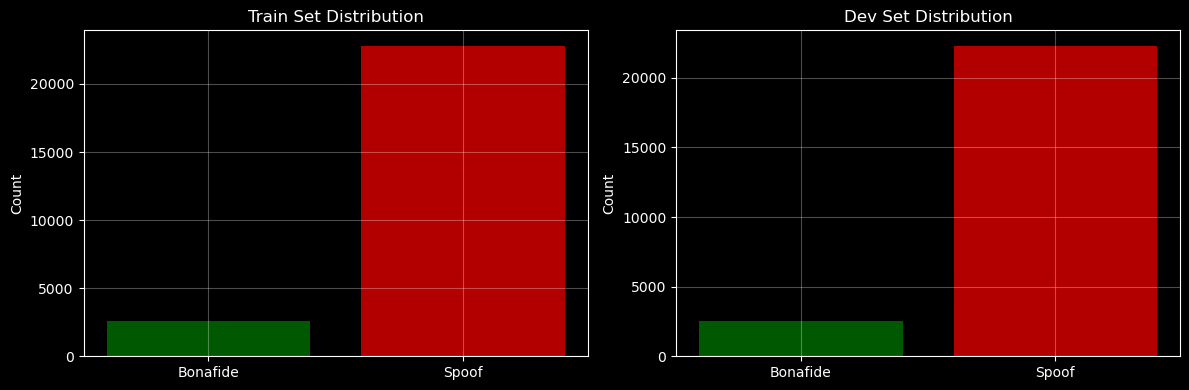


 NOTE: Severe class imbalance (~1:9 ratio)
   This is normal for ASVspoof2019
   We'll use weighted loss to handle this


In [8]:
import matplotlib.pyplot as plt
def analyze_dataset(dataset, split_name):
    labels = dataset.metadata['label'].values
    bonafide_count = (labels == 'bonafide').sum()
    spoof_count = (labels == 'spoof').sum()
    total = len(labels)
    
    print(f"\n{'='*60}")
    print(f"{split_name.upper()} DATASET STATISTICS")
    print(f"{'='*60}")
    print(f"Total samples:    {total:,}")
    print(f"Bonafide samples: {bonafide_count:,} ({100*bonafide_count/total:.2f}%)")
    print(f"Spoof samples:    {spoof_count:,} ({100*spoof_count/total:.2f}%)")
    print(f"Imbalance ratio:  1:{spoof_count/bonafide_count:.2f}")
    print(f"{'='*60}")
    
    return bonafide_count, spoof_count

train_bonafide, train_spoof = analyze_dataset(train_dataset, 'train')
dev_bonafide, dev_spoof = analyze_dataset(dev_dataset, 'dev')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Bonafide', 'Spoof'], [train_bonafide, train_spoof], 
            color=['green', 'red'], alpha=0.7)
axes[0].set_ylabel('Count')
axes[0].set_title('Train Set Distribution')
axes[0].grid(True, alpha=0.3)

axes[1].bar(['Bonafide', 'Spoof'], [dev_bonafide, dev_spoof], 
            color=['green', 'red'], alpha=0.7)
axes[1].set_ylabel('Count')
axes[1].set_title('Dev Set Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n NOTE: Severe class imbalance (~1:9 ratio)")
print(f"   This is normal for ASVspoof2019")
print(f"   We'll use weighted loss to handle this")

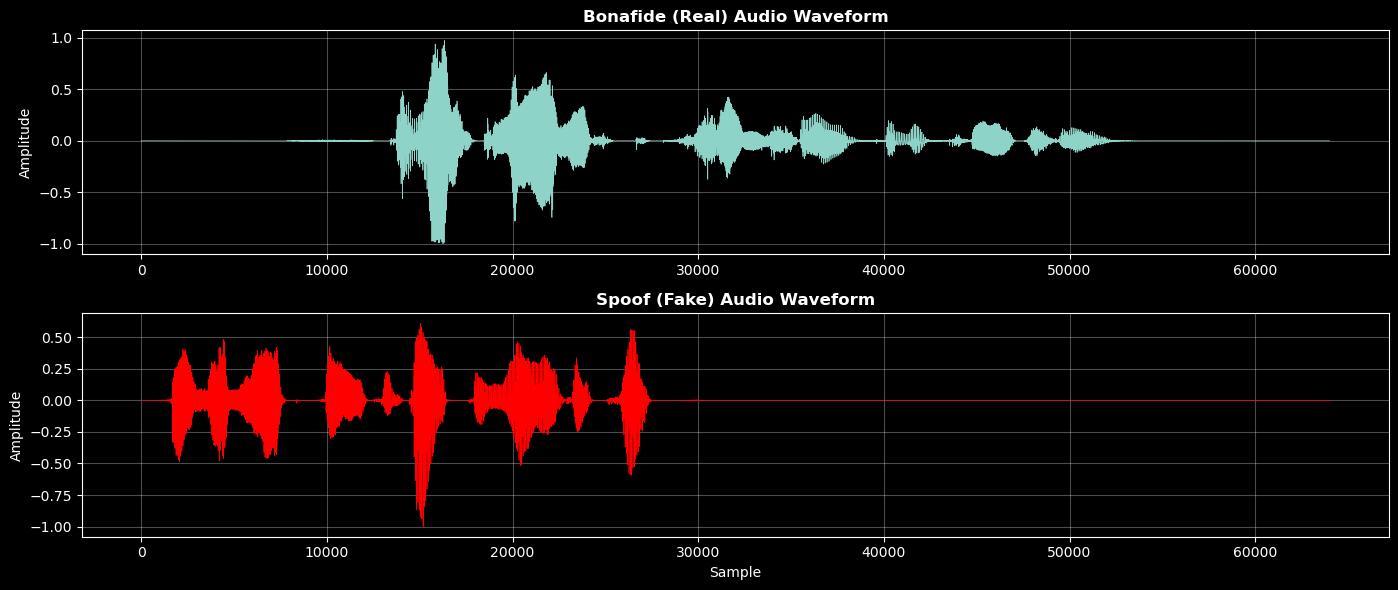


Waveforms visualized successfully
Notice the differences in patterns between bonafide and spoof audio


In [9]:
bonafide_idx = train_dataset.metadata[train_dataset.metadata['label'] == 'bonafide'].index[0]
spoof_idx = train_dataset.metadata[train_dataset.metadata['label'] == 'spoof'].index[0]

bonafide_wave, _ = train_dataset[bonafide_idx]
spoof_wave, _ = train_dataset[spoof_idx]

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(bonafide_wave[0].numpy(), linewidth=0.5)
axes[0].set_title('Bonafide (Real) Audio Waveform', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(spoof_wave[0].numpy(), linewidth=0.5, color='red')
axes[1].set_title('Spoof (Fake) Audio Waveform', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nWaveforms visualized successfully")
print(f"Notice the differences in patterns between bonafide and spoof audio")

In [10]:
print(f"\n{'='*60}")
print("SETUP VERIFICATION CHECKLIST")
print(f"{'='*60}")

checks = [
    ("GPU available", torch.cuda.is_available()),
    ("Data directories exist", all_good),
    ("Train dataset loaded", len(train_dataset) > 0),
    ("Dev dataset loaded", len(dev_dataset) > 0),
]

all_passed = True
for check_name, passed in checks:
    status = "✓" if passed else "✗"
    print(f" {status} {check_name}")
    if not passed:
        all_passed = False

print(f"\n{'='*60}\n")

if all_passed:
    print(" ALL CHECKS PASSED!")
    print("\n You're ready to proceed to:")
    print(" 01_train_cnn.ipynb - Train your CNN model")
    print(" 02_train_rnn.ipynb - Train your RNN model")
    print(" 03_train_transformer.ipynb - Train your Transformer model")
else:
    print(" ✗ SOME CHECKS FAILED")
    print("\n Fix the issues above before proceeding to training")


SETUP VERIFICATION CHECKLIST
 ✓ GPU available
 ✓ Data directories exist
 ✓ Train dataset loaded
 ✓ Dev dataset loaded


 ALL CHECKS PASSED!

 You're ready to proceed to:
 01_train_cnn.ipynb - Train your CNN model
 02_train_rnn.ipynb - Train your RNN model
 03_train_transformer.ipynb - Train your Transformer model
